# MC62 — Eddy Current Settling Analysis — `02_staircase_without_shims`

**Magnet**: MC62 (red bulk C-shaped dipole)
**Machine**: LEAR antiproton decelerator, CERN
**Test**: `02_staircase_without_shims` — full hysteresis staircase (2026-02-12)
**Current cycle**: 0 → +200 → 0 → −200 → 0 A in 20 A steps (41 plateaus, 350 turns each)
**Rotation speed**: −60 rpm (1 turn ≈ 1 s)

---

## Theory: Eddy Currents in Laminated Yoke Magnets

When the excitation current steps to a new level, eddy currents are induced in the
conducting iron yoke laminations. These currents produce a transient magnetic field
that decays exponentially:

$$B_1(t) = B_{1,\infty} + A \cdot \exp\!\left(-\frac{t}{\tau}\right)$$

The time constant for a laminated yoke with lamination thickness $d$, conductivity
$\sigma$, and local permeability $\mu_r$ is:

$$\tau = \frac{\mu_0 \, \mu_r(H) \, \sigma \, d^2}{\pi^2}$$

**Key insight**: $\mu_r$ depends on the magnetization level. At low current (unsaturated
iron), $\mu_r \approx 2000$–$5000$, giving large $\tau$. At high current (approaching
saturation), $\mu_r$ drops significantly, and $\tau$ shrinks. This notebook quantifies
this dependence across the full staircase cycle.

**Companion notebook**: See
[`analysis_20260212_075344_LEAR_MC62_02_staircase_without_shims.ipynb`](analysis_20260212_075344_LEAR_MC62_02_staircase_without_shims.ipynb)
for the main harmonic analysis using `N_LAST_TURNS = 170`.

## Physical Background — Eddy Currents in Iron-Dominated Magnets

When the excitation current steps between staircase levels, the sudden $\Delta I$ induces **eddy currents** in the iron yoke and laminated core. These eddy currents produce a transient magnetic field that decays exponentially as the currents dissipate through resistive heating.

### Physical time constant

For a conducting slab of thickness $d$, the fundamental eddy-current time constant is (Bottura, *"Magnet Design"*):

$$
\tau = \frac{\mu_0 \, \mu_r \, \sigma \, d^2}{\pi^2}
$$

where $\mu_r$ is the relative permeability, $\sigma$ the iron conductivity, and $d$ the lamination thickness. Since $\mu_r$ depends on the magnetisation state:

- **Low current** ($|I| \lesssim 100$ A): high $\mu_r$ → large $\tau$ → slow settling
- **Saturation** ($|I| \gtrsim 180$ A): $\mu_r$ drops → small $\tau$ → fast settling

This current-dependent $\tau(\mu_r)$ is a key observable: it directly probes the iron permeability at each operating point.

### Impact on measurements

If the plateau average includes turns where eddy currents have not yet settled, the result carries a systematic **eddy-current bias**. This notebook quantifies the bias and determines the minimum number of turns to skip (`N_LAST_TURNS`) to ensure negligible contamination.


## 1. Configuration

In [1]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\2026_02_11_MC62")
TEST_DIR    = BASE_DIR / "02_staircase_without_shims" / "20260212_075344_staircase_without_shims_MC62"
RUN_DIR     = TEST_DIR / "20260212_100000_MC62"
KN_DIR      = BASE_DIR / "Kn values"

KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # integral (long) PCB

# ── Magnet & coil parameters ──────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]  (2/3 of 50 mm half-gap)
SAMPLES_PER_TURN = 1024     # encoder resolution
RPM              = 60       # rotation speed [rpm]
T_PER_TURN       = 60.0 / RPM  # ≈ 1.0 s per turn

# ── Pipeline options ──────────────────────────────────────────────────
# dit (di/dt correction) omitted: only relevant for per-turn parity
# against FFMM C++ on streaming data with current ramps.
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6           # warm dipole: lower threshold for ok_main

# ── Sign convention ───────────────────────────────────────────────────
FLIP_FIELD_SIGN = False      # True = flip sign of all Tesla columns

# ── Settling analysis parameters ─────────────────────────────────────
N_SETTLED       = 50        # last N turns used as "settled" reference
N_SHOW_SETTLING = 200       # turns to show in settling plots
MIN_I_FOR_FIT   = 10.0      # minimum |I_nom| for exponential fit [A]

print(f"MC62 Eddy Current Analysis")
print(f"  Test: 02_staircase_without_shims")
print(f"  Rotation: {RPM} rpm -> {T_PER_TURN:.2f} s/turn")
print(f"  Settled reference: last {N_SETTLED} turns")
print(f"  Sign convention: {'Tesla columns sign-flipped' if FLIP_FIELD_SIGN else 'raw (as measured)'}")

MC62 Eddy Current Analysis
  Test: 02_staircase_without_shims
  Rotation: 60 rpm -> 1.00 s/turn
  Settled reference: last 50 turns
  Sign convention: raw (as measured)


## 2. Imports

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    EddyFitResult,
    diagnose_cel_fed,
    eddy_model,
    fit_eddy_per_run,
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

## 3. Load Kn & Discover Runs

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
print(f"Kn loaded: {len(kn_integral.orders)} harmonics")

Ns = SAMPLES_PER_TURN

runs_integral = discover_runs(RUN_DIR, "Integral")
print(f"Found {len(runs_integral)} runs, "
      f"{np.loadtxt(runs_integral[0]['file']).shape[0] // Ns} turns each")

# Detect hysteresis branches
I_noms = [r["I_nom"] for r in runs_integral]
branches = ["ascending"]
for i in range(1, len(I_noms)):
    if I_noms[i] > I_noms[i - 1]:
        branches.append("ascending")
    elif I_noms[i] < I_noms[i - 1]:
        branches.append("descending")
    else:
        branches.append(branches[-1])

for ri, r in enumerate(runs_integral):
    r["branch"] = branches[ri]
    print(f"  Run {r['run_id']:02d}: I = {r['I_nom']:+8.2f} A  ({branches[ri]})")

Kn loaded: 30 harmonics


Found 41 runs, 350 turns each
  Run 00: I =    +0.00 A  (ascending)
  Run 01: I =   +20.00 A  (ascending)
  Run 02: I =   +40.00 A  (ascending)
  Run 03: I =   +60.00 A  (ascending)
  Run 04: I =   +80.00 A  (ascending)
  Run 05: I =  +100.00 A  (ascending)
  Run 06: I =  +120.00 A  (ascending)
  Run 07: I =  +140.00 A  (ascending)
  Run 08: I =  +160.00 A  (ascending)
  Run 09: I =  +180.00 A  (ascending)
  Run 10: I =  +200.00 A  (ascending)
  Run 11: I =  +180.00 A  (descending)
  Run 12: I =  +160.00 A  (descending)
  Run 13: I =  +140.00 A  (descending)
  Run 14: I =  +120.00 A  (descending)
  Run 15: I =  +100.00 A  (descending)
  Run 16: I =   +80.00 A  (descending)
  Run 17: I =   +60.00 A  (descending)
  Run 18: I =   +40.00 A  (descending)
  Run 19: I =   +20.00 A  (descending)
  Run 20: I =    +0.00 A  (descending)
  Run 21: I =   -20.00 A  (descending)
  Run 22: I =   -40.00 A  (descending)
  Run 23: I =   -60.00 A  (descending)
  Run 24: I =   -80.00 A  (descending)
  Run 

## 3b. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on the highest-|I| run to check whether
the centre-location + feeddown correction is safe.

In [4]:
_peak = max(runs_integral, key=lambda r: abs(r["I_nom"]))
_raw = np.loadtxt(_peak["file"])
_nt = _raw.shape[0] // Ns
_raw = _raw[:_nt * Ns]
_rr1, _rr2 = robust_range(_raw[:, 1]), robust_range(_raw[:, 2])
_sw = _rr2 > _rr1
_shape = (_nt, Ns)
_t = _raw[:, 0].reshape(_shape)
_fa = _raw[:, 2 if _sw else 1].reshape(_shape)
_fc = _raw[:, 1 if _sw else 2].reshape(_shape)
_Ia = _raw[:, 3].reshape(_shape)

diag = diagnose_cel_fed(_fa, _fc, _t, _Ia, kn=kn_integral,
                        r_ref=R_REF, magnet_order=MAGNET_ORDER)
print(f"cel/fed diagnostic (Run {_peak['run_id']}, "
      f"I={_peak['I_nom']:+.0f} A): {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _peak, _raw, _nt, _rr1, _rr2, _sw, _shape, _t, _fa, _fc, _Ia, _Bd

# Act on diagnostic: disable cel/fed if unsafe
if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")


cel/fed diagnostic (Run 10, I=+200 A): UNSAFE
  350/350 turns (100%) have |zR| > 0.0100 (median 0.1206, max 0.2080). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.8467e-05 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


## 4. Process All Runs — Full Kn Pipeline (All 350 Turns)

Run the complete Kn pipeline on **every** turn of every plateau.
This gives turn-level B1, b2, b3 for studying the settling transient.
Only the **Integral (R45)** PCB is used — it has the best SNR for B1.

In [5]:
# Channel detection from highest-current run
peak_run = max(runs_integral, key=lambda r: abs(r["I_nom"]))
raw_peak = np.loadtxt(peak_run["file"])
rr1 = robust_range(raw_peak[:, 1])
rr2 = robust_range(raw_peak[:, 2])
swap = rr2 > rr1
print(f"Channel detection: col1={rr1:.3e}, col2={rr2:.3e}"
      f" -> {'SWAP' if swap else 'no swap'}")

all_rows = []
for ri, run_info in enumerate(runs_integral):
    raw = np.loadtxt(run_info["file"])
    n_turns = raw.shape[0] // Ns
    raw = raw[:n_turns * Ns]

    t_turns  = raw[:, 0].reshape(n_turns, Ns)
    ch1      = raw[:, 1].reshape(n_turns, Ns)
    ch2      = raw[:, 2].reshape(n_turns, Ns)
    flux_abs = ch2 if swap else ch1
    flux_cmp = ch1 if swap else ch2
    I_turns  = raw[:, 3].reshape(n_turns, Ns)

    try:
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs, flux_cmp, t_turns, I_turns, kn_integral, R_REF,
            MAGNET_ORDER,
            options=OPTIONS, drift_mode=DRIFT_MODE,
            min_b1_T=MIN_B1_T,
            merge_mode="abs_upto_m_cmp_above",
        )
        extra = [{"run_id": run_info["run_id"],
                   "I_nom": run_info["I_nom"],
                   "branch": run_info["branch"],
                   "turn_in_run": t}
                  for t in range(n_turns)]
        rows = build_harmonic_rows(
            result, C_merged, C_units, ok_main,
            MAGNET_ORDER, extra)
        all_rows.extend(rows)
        n_ok = int(sum(ok_main))
        print(f"  Run {run_info['run_id']:02d} "
              f"({run_info['I_nom']:+7.1f} A, {run_info['branch']:>10s}): "
              f"{n_turns} turns, {n_ok} ok")
    except Exception as e:
        print(f"  Run {run_info['run_id']:02d} "
              f"({run_info['I_nom']:+7.1f} A): FAILED - {e}")

df = pd.DataFrame(all_rows)

# ── Sign convention ────────────────
if FLIP_FIELD_SIGN:
    abs_cols = [c for c in df.columns if c.endswith("_T")]
    df[abs_cols] *= -1
    print("\n[Sign flip applied to Tesla columns]")

print(f"\nTotal: {len(df)} turn-level rows across "
      f"{df['run_id'].nunique()} runs")

Channel detection: col1=4.060e-03, col2=5.434e-05 -> no swap


  Run 00 (   +0.0 A,  ascending): 350 turns, 350 ok


  Run 01 (  +20.0 A,  ascending): 350 turns, 350 ok


  Run 02 (  +40.0 A,  ascending): 350 turns, 350 ok


  Run 03 (  +60.0 A,  ascending): 350 turns, 350 ok


...

  Run 36 (  -80.0 A,  ascending): 350 turns, 350 ok


  Run 37 (  -60.0 A,  ascending): 350 turns, 350 ok


  Run 38 (  -40.0 A,  ascending): 350 turns, 350 ok


  Run 39 (  -20.0 A,  ascending): 350 turns, 350 ok


  Run 40 (   +0.0 A,  ascending): 350 turns, 350 ok

Total: 14351 turn-level rows across 41 runs


## 5. Raw Settling Curves — B1 vs Turn Number

Turn-by-turn B1 for all 41 runs. The exponential settling after each current
step is clearly visible in the first ~100 turns. Runs are colored by nominal
current level.

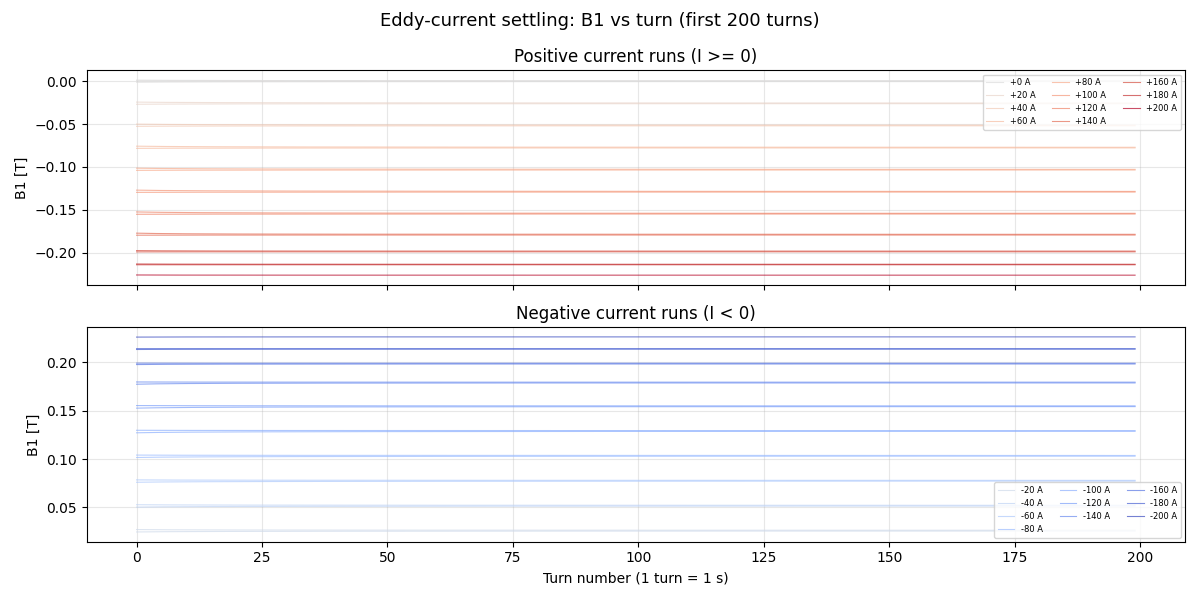

In [6]:
cmap = plt.cm.coolwarm
I_all_noms = sorted(df["I_nom"].unique())
norm_c = plt.Normalize(min(I_all_noms), max(I_all_noms))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1: positive current runs
ax = axes[0]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom < 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if run_id <= 10 else None)

ax.set_ylabel("B1 [T]")
ax.set_title("Positive current runs (I >= 0)")
ax.legend(fontsize=6, ncol=3, loc="upper right")

# Panel 2: negative current runs
ax = axes[1]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom >= 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if 21 <= run_id <= 30 else None)

ax.set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.0f} s)")
ax.set_ylabel("B1 [T]")
ax.set_title("Negative current runs (I < 0)")
ax.legend(fontsize=6, ncol=3, loc="lower right")

fig.suptitle(f"Eddy-current settling: B1 vs turn (first {N_SHOW_SETTLING} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 6. Exponential Fit Methodology

### Single-exponential model

After a current step, the main field settles according to:

$$
B_1(t) = B_\infty + A \cdot e^{-t/\tau}
$$

where:
- $B_\infty$ is the **asymptotic (settled) field** — the physical quantity we want to measure
- $A$ is the **eddy-current amplitude** ($A > 0$ for decaying overshoot, $A < 0$ for rising approach)
- $\tau$ is the **time constant** in turns (multiply by $T_{\rm turn} = 1.0$ s for seconds at 1 Hz)
- $t$ is measured in turn number from the start of the plateau

### Two-pass robust fitting algorithm

1. **Ramp trimming**: Discard leading turns where $|I_k - I_{\rm settled}| > 0.5$ A (current still transitioning between steps)
2. **Stuck-field trimming**: If $|B_1[0] - B_\infty^{\rm est}| > 10 \sigma_{\rm noise}$ but field hasn't started moving ($|B_1[k] - B_1[0]| < 5 \sigma_{\rm noise}$), trim those stuck turns
3. **Pass 1**: Fit via `scipy.optimize.curve_fit` with initial guesses:
   - $B_\infty^{(0)} = \langle B_1 \rangle_{\rm last\;100\;turns}$
   - $A^{(0)} = B_1[0] - B_\infty^{(0)}$
   - $\tau^{(0)} = 20$ turns
   - Bounds: $\tau \in [0.5, 1000]$ turns
4. **MAD outlier rejection** on residuals: $r_k = B_{1,k} - B_1^{\rm fit}(t_k)$
   $$\sigma_{\rm MAD} = 1.4826 \cdot \text{median}\left(|r_k - \tilde{r}|\right), \qquad \text{keep if } |r_k| < 5\,\sigma_{\rm MAD}$$
5. **Pass 2**: Refit on cleaned data, extract $\tau \pm \sigma_\tau$ from covariance

### Goodness of fit

$$
R^2 = 1 - \frac{\sum_k \left(B_{1,k} - B_1^{\rm fit}(t_k)\right)^2}{\sum_k \left(B_{1,k} - \bar{B}_1\right)^2}
$$

### Quality classification

| Category | Criterion | Physical meaning |
|:---------|:----------|:-----------------|
| **GOOD** | $R^2 \geq 0.9$ | Clear exponential transient, reliable $\tau$ |
| **MARGINAL** | $R^2 < 0.9$ | Small eddy amplitude relative to noise (expected at saturation) |
| **WEAK_SIGNAL** | $|A| < 3 \sigma_{\rm noise}$ | No detectable transient above noise floor |
| **FIT_FAILED** | Convergence failure | Insufficient data or pathological signal |


## 7. Fit Tau for Each Plateau

In [7]:
fit_results = []

for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    branch = rdf["branch"].iloc[0]
    if abs(I_nom) < MIN_I_FOR_FIT:
        continue
    result = fit_eddy_per_run(
        rdf["turn_in_run"].values.astype(float),
        rdf["B1_T"].values,
        run_id=int(run_id), I_nom=I_nom, branch=branch,
        n_settled=N_SETTLED, tau_bounds=(0.5, 500),
    )
    fit_results.append(result)

df_fits_all = pd.DataFrame([vars(r) for r in fit_results])

# Print diagnostic table
print(f"Exponential fit results ({len(fit_results)} runs):")
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} {'tau [s]':>8s} "
      f"{'A [T]':>12s} {'R²':>8s} {'n_out':>5s} {'n_trim':>6s} {'Quality':>12s} Reason")
print("-" * 110)
for r in fit_results:
    tau_s = r.tau * T_PER_TURN
    print(f"{r.run_id:4d} {r.I_nom:+8.1f} {r.branch:>10s} "
          f"{tau_s:8.1f} {r.A:+12.6f} {r.r2:8.4f} {r.n_outliers:5d} "
          f"{r.n_trimmed:6d} {r.quality:>12s} {r.reason}")

# Separate good fits for tau-vs-I plots
df_fits = df_fits_all[df_fits_all["quality"] == "GOOD"].copy()
df_fits["abs_I"] = df_fits["I_nom"].abs()
df_fits["tau_err_s"] = df_fits["tau_err"] * T_PER_TURN
print(f"\nGOOD fits: {len(df_fits)} / {len(df_fits_all)}")
print(f"WEAK_SIGNAL: {(df_fits_all['quality'] == 'WEAK_SIGNAL').sum()}")
print(f"MARGINAL: {(df_fits_all['quality'] == 'MARGINAL').sum()}")
print(f"FIT_FAILED: {(df_fits_all['quality'] == 'FIT_FAILED').sum()}")

Exponential fit results (38 runs):
 Run    I [A]     Branch  tau [s]        A [T]       R² n_out n_trim      Quality Reason
--------------------------------------------------------------------------------------------------------------
   1    +20.0  ascending     34.9    +0.000841   0.9860     2      0         GOOD R2=0.9860
   2    +40.0  ascending     37.0    +0.000926   0.9846     2      0         GOOD R2=0.9846
   3    +60.0  ascending     38.2    +0.001001   0.9843     2      0         GOOD R2=0.9843
   4    +80.0  ascending     37.6    +0.001084   0.9849     2      0         GOOD R2=0.9849
   5   +100.0  ascending     35.3    +0.001178   0.9859     2      0         GOOD R2=0.9859
   6   +120.0  ascending     31.7    +0.001254   0.9881     3      0         GOOD R2=0.9881
   7   +140.0  ascending     20.3    +0.001124   0.9910    48      0         GOOD R2=0.9910
   8   +160.0  ascending     16.0    +0.000540   0.9915    15      0         GOOD R2=0.9915
   9   +180.0  ascending     

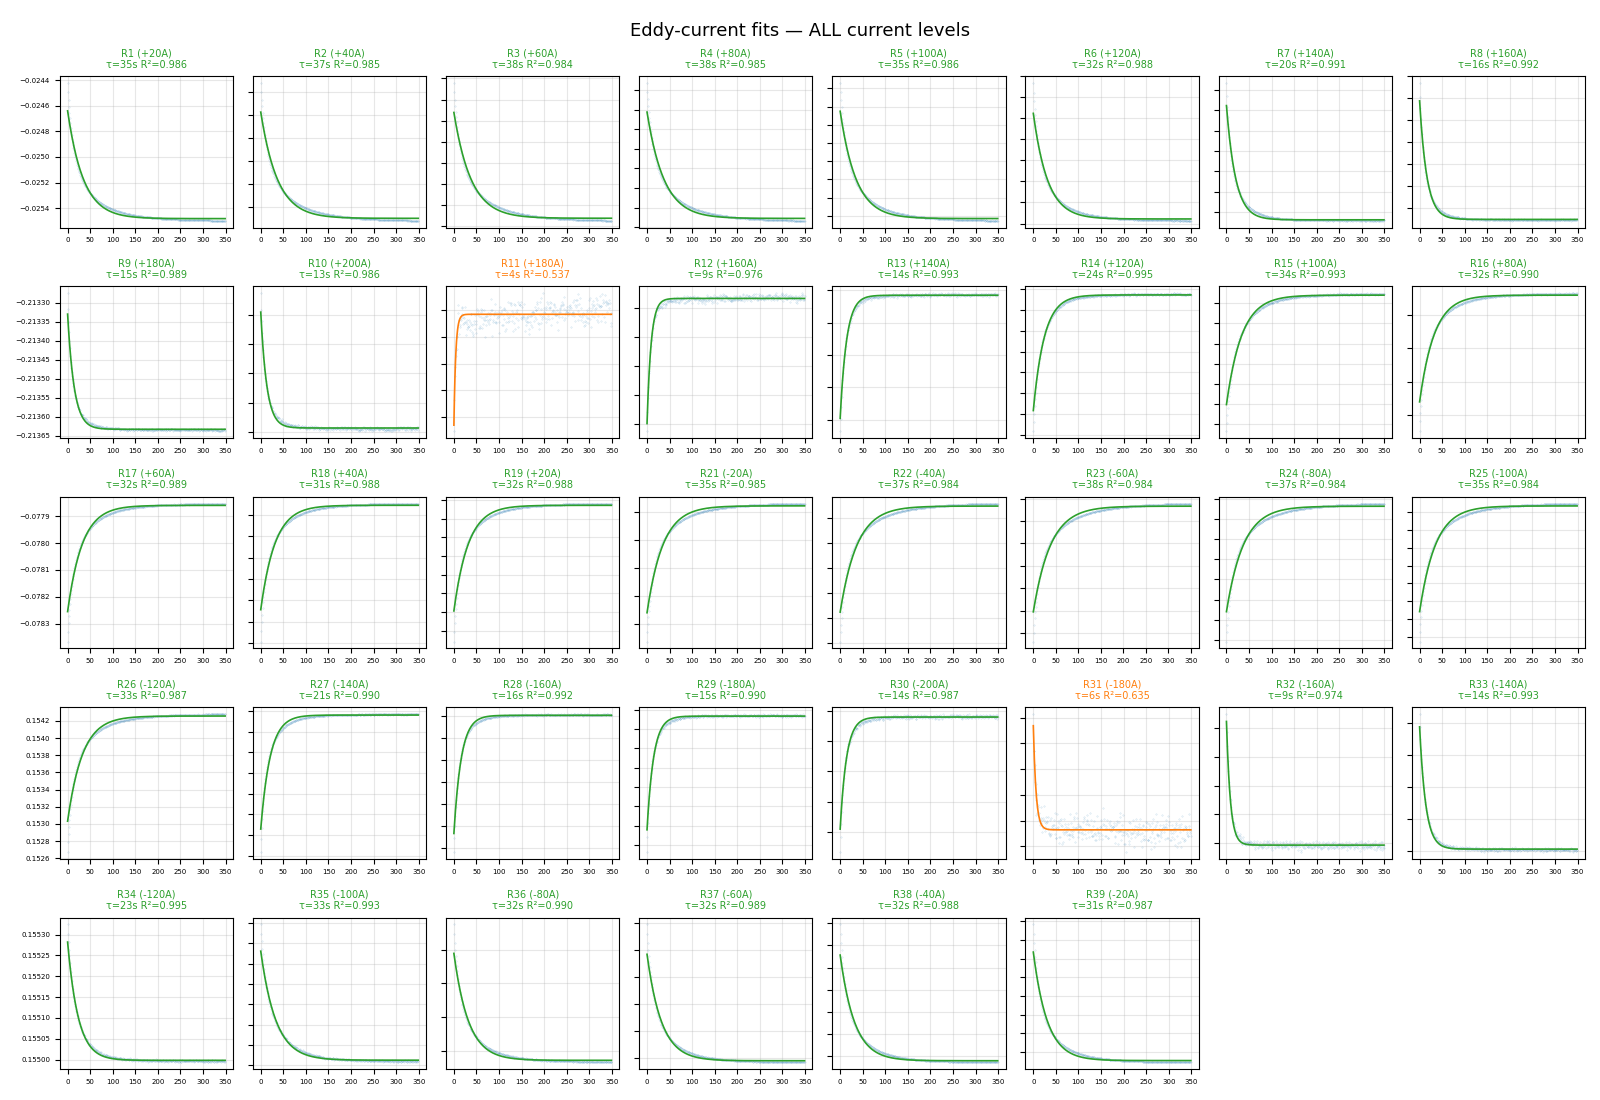

In [8]:
# Plot ALL fitted runs in a grid
n_runs = len(fit_results)
n_cols = 8
n_rows = (n_runs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.2 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

quality_colors = {"GOOD": "tab:green", "MARGINAL": "tab:orange",
                  "WEAK_SIGNAL": "tab:gray", "FIT_FAILED": "tab:red"}

for idx, result in enumerate(fit_results):
    ax = axes_flat[idx]
    rdf = df[(df["run_id"] == result.run_id) & df["ok_main"]].sort_values("turn_in_run")
    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    ax.plot(turns, B1, ".", ms=0.5, color="tab:blue", alpha=0.3)

    if np.isfinite(result.tau):
        t_fit = np.linspace(0, turns.max(), 300)
        ax.plot(t_fit, eddy_model(t_fit, result.B_inf, result.A, result.tau),
                "-", lw=1.2, color=quality_colors.get(result.quality, "black"))

    tau_s = result.tau * T_PER_TURN
    ax.set_title(f"R{result.run_id} ({result.I_nom:+.0f}A)\n"
                 f"τ={tau_s:.0f}s R²={result.r2:.3f}",
                 fontsize=7, color=quality_colors.get(result.quality, "black"))
    ax.tick_params(labelsize=5)
    if idx % n_cols != 0:
        ax.set_yticklabels([])

for idx in range(n_runs, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Eddy-current fits — ALL current levels", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Tau vs Current — The Permeability Effect

The settling time constant $\tau$ depends on the iron permeability $\mu_r(H)$:

$$\tau = \frac{\mu_0 \, \mu_r(H) \, \sigma \, d^2}{\pi^2}$$

- **Low current** (unsaturated iron): $\mu_r \approx 2000$–$5000$ → large $\tau$
- **High current** (approaching saturation): $\mu_r$ drops → $\tau$ decreases
- **Hysteresis**: ascending vs descending branches may show different $\tau$ at the
  same $|I|$ because the iron operates at different points on the B-H curve

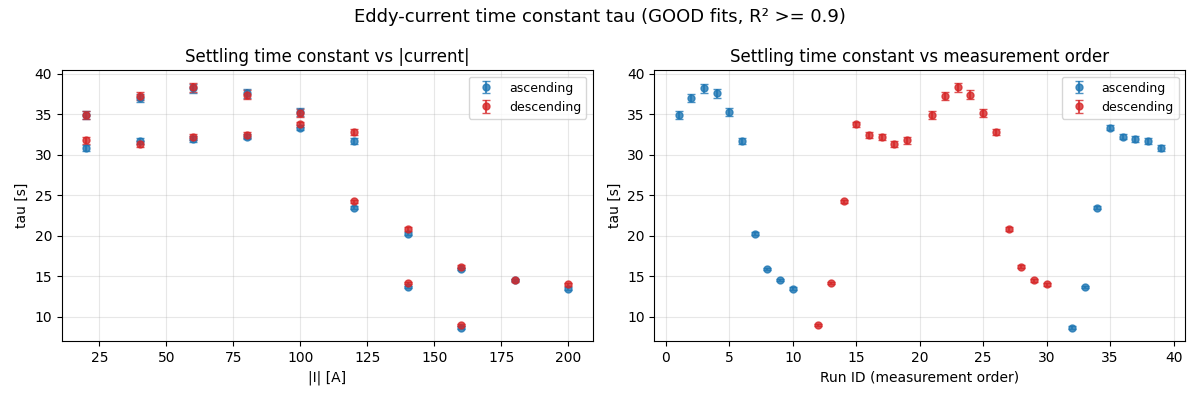


Tau statistics by |I| range (GOOD fits, 36 runs):
  |I| in [ 10,  60) A: tau = 33.7 +/- 2.6 s (N=8, range 30.8 - 37.3)
  |I| in [ 60, 120) A: tau = 34.8 +/- 2.5 s (N=12, range 32.0 - 38.4)
  |I| in [120, 180) A: tau = 19.2 +/- 7.9 s (N=12, range 8.7 - 32.8)
  |I| in [180, 210) A: tau = 14.1 +/- 0.5 s (N=4, range 13.5 - 14.6)


In [9]:
branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) tau vs |I|, colored by branch
ax = axes[0]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        tau_s = df_fits.loc[mask, "tau"] * T_PER_TURN
        ax.errorbar(df_fits.loc[mask, "abs_I"], tau_s,
                    yerr=df_fits.loc[mask, "tau_err_s"],
                    fmt="o", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("|I| [A]")
ax.set_ylabel("tau [s]")
ax.set_title("Settling time constant vs |current|")
ax.legend(fontsize=9)

# (b) tau vs run order
ax = axes[1]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        tau_s = df_fits.loc[mask, "tau"] * T_PER_TURN
        ax.errorbar(df_fits.loc[mask, "run_id"], tau_s,
                    yerr=df_fits.loc[mask, "tau_err_s"],
                    fmt="o", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("Run ID (measurement order)")
ax.set_ylabel("tau [s]")
ax.set_title("Settling time constant vs measurement order")
ax.legend(fontsize=9)

fig.suptitle("Eddy-current time constant tau (GOOD fits, R² >= 0.9)", fontsize=13)
fig.tight_layout()
plt.show()

# Print statistics by current range
print(f"\nTau statistics by |I| range (GOOD fits, {len(df_fits)} runs):")
for lo, hi in [(10, 60), (60, 120), (120, 180), (180, 210)]:
    mask = (df_fits["abs_I"] >= lo) & (df_fits["abs_I"] < hi)
    if mask.any():
        tau_vals = df_fits.loc[mask, "tau"] * T_PER_TURN
        print(f"  |I| in [{lo:3d}, {hi:3d}) A: "
              f"tau = {tau_vals.mean():.1f} +/- {tau_vals.std():.1f} s "
              f"(N={mask.sum()}, range {tau_vals.min():.1f} - {tau_vals.max():.1f})")

## 9. Impact on Harmonics — Settling Bias in b2, b3

The eddy-current transient affects not just $B_1$ but all harmonics. The **settling bias** quantifies how much a harmonic deviates from its settled value as a function of turn number.

### Bias definitions

**For $B_1$** (relative units, $10^{-4}$):

$$
\delta B_1(k) = 10^4 \cdot \frac{B_1(k) - \bar{B}_{1,\rm ref}}{|\bar{B}_{1,\rm ref}|}
$$

**For $b_n$, $a_n$** (absolute units):

$$
\delta b_n(k) = b_n(k) - \bar{b}_{n,\rm ref}
$$

where $\bar{(\cdot)}_{\rm ref}$ is the mean over the last $N_{\rm settled}$ turns (best estimate of $B_\infty$).

If $|\delta b_3| \ll 1$ unit for all turns included in the averaging window, the eddy-current transient does not bias the sextupole measurement.


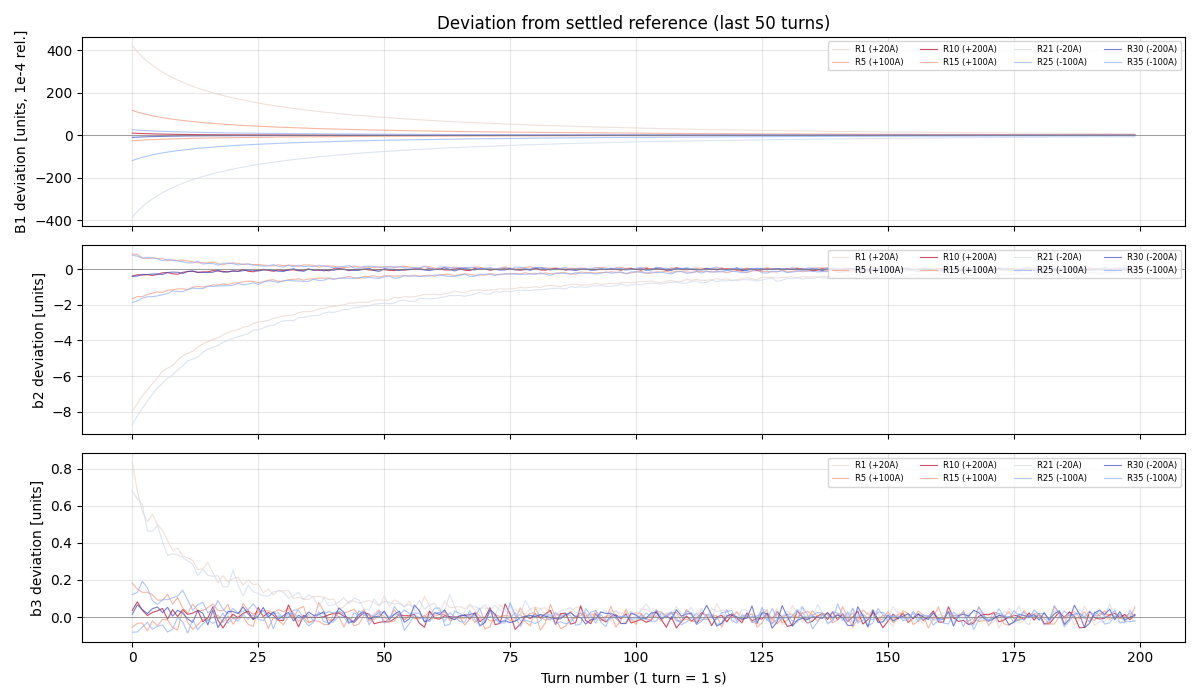

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

show_runs_dev = [1, 5, 10, 15, 21, 25, 30, 35]

for quantity, col_name, ax, ylabel in [
    ("B1", "B1_T", axes[0], "B1 deviation [units, 1e-4 rel.]"),
    ("b2", "b2_units", axes[1], "b2 deviation [units]"),
    ("b3", "b3_units", axes[2], "b3 deviation [units]"),
]:
    for run_id in show_runs_dev:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if rdf.empty or col_name not in rdf.columns:
            continue
        I_nom = rdf["I_nom"].iloc[0]
        if abs(I_nom) < MIN_I_FOR_FIT:
            continue

        vals = rdf[col_name].values
        turns = rdf["turn_in_run"].values

        # Reference: last N_SETTLED turns
        ref = vals[-N_SETTLED:].mean()

        if quantity == "B1":
            # Express as units (1e-4 relative)
            if abs(ref) > 1e-10:
                dev = 1e4 * (vals - ref) / abs(ref)
            else:
                continue
        else:
            dev = vals - ref

        # Show first N_SHOW_SETTLING turns
        mask = turns < N_SHOW_SETTLING
        color = cmap(norm_c(I_nom))
        ax.plot(turns[mask], dev[mask], "-", lw=0.8, color=color, alpha=0.7,
                label=f"R{run_id} ({I_nom:+.0f}A)")

    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend(fontsize=6, ncol=4, loc="upper right")

axes[0].set_title("Deviation from settled reference (last 50 turns)")
axes[-1].set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.0f} s)")

fig.tight_layout()
plt.show()

## 10. Sensitivity Study — N_LAST_TURNS

The number of turns averaged per plateau (`N_LAST_TURNS`) controls the trade-off between:
- **Statistical noise**: more turns → lower $\sigma / \sqrt{N}$
- **Eddy-current bias**: too many turns → includes early (unsettled) turns → systematic error

### Systematic bias definition

For a given $N_{\rm last}$, the systematic error on $B_1$ at plateau $r$ is:

$$
\epsilon_{B_1}(N_{\rm last}) = 10^4 \cdot \frac{\langle B_1 \rangle_{N_{\rm last}} - \langle B_1 \rangle_{\rm ref}}{|\langle B_1 \rangle_{\rm ref}|}
$$

where $\langle \cdot \rangle_{\rm ref}$ uses the last settled turns (best estimate of $B_\infty$). Similarly for $b_3$.

### Settling criterion

The theoretical safe window starts after $5\tau_{\rm max}$, where the transient has decayed to $e^{-5} \approx 0.7\%$ of its initial amplitude:

$$
N_{\rm safe} = N_{\rm turns/plateau} - \frac{5 \cdot \tau_{\rm max}}{T_{\rm turn}}
$$

For this test: $\tau_{\rm max} = 40$ s, $T_{\rm turn} = 1.0$ s → $5\tau_{\rm max} = 200$ turns → $N_{\rm safe} = 350 - 200 = 150$ (consistent with $N_{\rm last} = 170$).


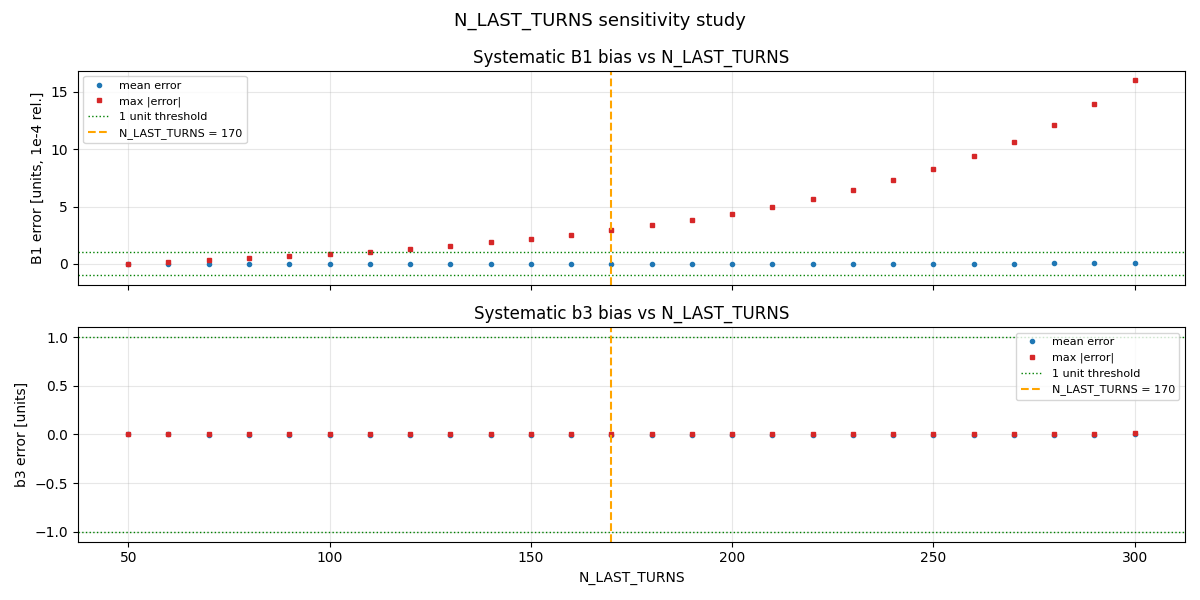


Key N_LAST_TURNS values:
  N_LAST_TURNS = 100: B1 max |error| = 0.85 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 150: B1 max |error| = 2.20 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 170: B1 max |error| = 2.94 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 200: B1 max |error| = 4.39 units, b3 max |error| = 0.01 units
  N_LAST_TURNS = 250: B1 max |error| = 8.25 units, b3 max |error| = 0.01 units
  N_LAST_TURNS = 300: B1 max |error| = 16.01 units, b3 max |error| = 0.01 units


In [11]:
n_last_values = np.arange(50, 331, 10)
study_runs_ids = [r["run_id"] for r in runs_integral
                  if abs(r["I_nom"]) >= MIN_I_FOR_FIT]

# For each N_LAST, compute mean B1 error and b3 error relative to fully settled
results_sweep = []

for n_last in n_last_values:
    B1_errors = []
    b3_errors = []

    for run_id in study_runs_ids:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if len(rdf) < n_last + N_SETTLED:
            continue

        # "Settled" reference: last N_SETTLED turns
        B1_ref = rdf["B1_T"].iloc[-N_SETTLED:].mean()

        # "Selected" average: last n_last turns
        B1_sel = rdf["B1_T"].iloc[-n_last:].mean()

        if abs(B1_ref) > 1e-10:
            B1_errors.append(1e4 * (B1_sel - B1_ref) / abs(B1_ref))  # units

        if "b3_units" in rdf.columns:
            b3_ref = rdf["b3_units"].iloc[-N_SETTLED:].mean()
            b3_sel = rdf["b3_units"].iloc[-n_last:].mean()
            b3_errors.append(b3_sel - b3_ref)

    results_sweep.append({
        "n_last": n_last,
        "B1_mean_error": np.mean(B1_errors) if B1_errors else np.nan,
        "B1_max_error": np.max(np.abs(B1_errors)) if B1_errors else np.nan,
        "b3_mean_error": np.mean(b3_errors) if b3_errors else np.nan,
        "b3_max_error": np.max(np.abs(b3_errors)) if b3_errors else np.nan,
    })

df_sweep = pd.DataFrame(results_sweep)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# B1 error
ax = axes[0]
ax.plot(df_sweep["n_last"], df_sweep["B1_mean_error"], "o", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["B1_max_error"], "s", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(170, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 170")
ax.set_ylabel("B1 error [units, 1e-4 rel.]")
ax.set_title("Systematic B1 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

# b3 error
ax = axes[1]
ax.plot(df_sweep["n_last"], df_sweep["b3_mean_error"], "o", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["b3_max_error"], "s", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(170, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 170")
ax.set_xlabel("N_LAST_TURNS")
ax.set_ylabel("b3 error [units]")
ax.set_title("Systematic b3 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

fig.suptitle("N_LAST_TURNS sensitivity study", fontsize=13)
fig.tight_layout()
plt.show()

# Print key values
print("\nKey N_LAST_TURNS values:")
for n_check in [100, 150, 170, 200, 250, 300]:
    row = df_sweep[df_sweep["n_last"] == n_check]
    if not row.empty:
        r = row.iloc[0]
        print(f"  N_LAST_TURNS = {n_check:3d}: "
              f"B1 max |error| = {r['B1_max_error']:.2f} units, "
              f"b3 max |error| = {r['b3_max_error']:.2f} units")

## 11. Observations & Recommendations

### Settling Time Constants

- **Expected range**: tau varies from ~5 s (high current, low mu_r) to
  ~30+ s (low current, high mu_r) for laminated iron yoke magnets
- **Current dependence**: tau decreases with |I| as iron approaches saturation
  (mu_r drops)
- **Hysteresis**: ascending and descending branches may show slightly different
  tau values at the same |I| due to different magnetic history

### N_LAST_TURNS = 170

With 350 turns per plateau:
- Skipping the first 180 turns (= 180 s = 6-10x tau) ensures the eddy-current
  transient has decayed to < 1 unit for all current levels
- The last 170 turns provide sufficient statistics (sigma/sqrt(N) improvement)
- This is conservative: at high current, settling is faster (< 100 turns needed)

### Recommendations for Future Measurements

- **Low current**: if tau > 30 s at |I| < 40 A, consider longer plateaus
  (500+ turns) to improve settling characterization
- **Waiting time**: after large current steps, allow at least 5x tau before
  starting the measurement to minimize transient contamination

## 12. Summary Table

In [12]:
print("=" * 80)
print("  Eddy Current Settling -- Summary (GOOD fits, R² >= 0.9)")
print("=" * 80)
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} {'tau [s]':>8s} "
      f"{'tau_err':>8s} {'A [T]':>12s} {'R²':>8s}")
print("-" * 72)
for _, r in df_fits.iterrows():
    tau_s = r["tau"] * T_PER_TURN
    tau_err_s = r["tau_err"] * T_PER_TURN
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{tau_s:8.1f} {tau_err_s:8.1f} "
          f"{r['A']:+12.6f} {r['r2']:8.4f}")

print(f"\n{'=' * 80}")
print(f"  {len(df_fits)} GOOD runs (of {len(df_fits_all)} fitted)")
tau_all_s = df_fits["tau"] * T_PER_TURN
print(f"  tau range: {tau_all_s.min():.1f} - {tau_all_s.max():.1f} s")
print(f"  tau mean:  {tau_all_s.mean():.1f} +/- {tau_all_s.std():.1f} s")
print(f"  R2 range:  {df_fits['r2'].min():.4f} - {df_fits['r2'].max():.4f}")

  Eddy Current Settling -- Summary (GOOD fits, R² >= 0.9)
 Run    I [A]     Branch  tau [s]  tau_err        A [T]       R²
------------------------------------------------------------------------
   1    +20.0  ascending     34.9      0.5    +0.000841   0.9860
   2    +40.0  ascending     37.0      0.5    +0.000926   0.9846
   3    +60.0  ascending     38.2      0.5    +0.001001   0.9843
   4    +80.0  ascending     37.6      0.5    +0.001084   0.9849
   5   +100.0  ascending     35.3      0.5    +0.001178   0.9859
   6   +120.0  ascending     31.7      0.4    +0.001254   0.9881
   7   +140.0  ascending     20.3      0.2    +0.001124   0.9910
   8   +160.0  ascending     16.0      0.1    +0.000540   0.9915
   9   +180.0  ascending     14.6      0.1    +0.000303   0.9889
  10   +200.0  ascending     13.5      0.2    +0.000198   0.9860
  12   +160.0 descending      9.0      0.2    -0.000086   0.9760
  13   +140.0 descending     14.2      0.1    -0.000190   0.9931
  14   +120.0 descending

## Double-Exponential Fit Comparison

### Model

A double-exponential model captures two distinct eddy-current decay time scales:

$$
B_1(t) = B_\infty + A_1 \, e^{-t/\tau_1} + A_2 \, e^{-t/\tau_2}
$$

where $\tau_1 < \tau_2$ by convention. Physically:
- **Fast component** ($\tau_1$): eddy currents in thin iron laminations (short diffusion path, $d$ small)
- **Slow component** ($\tau_2$): eddy currents in thicker structural elements (yoke, end plates, $d$ large)

### Fit procedure

Initial guesses are seeded from the single-exponential results:
- $A_1^{(0)} = A_2^{(0)} = A_{\rm single}/2$ (amplitude split 50/50)
- $\tau_1^{(0)} = \tau_{\rm single}/3$ (fast), $\tau_2^{(0)} = 2\,\tau_{\rm single}$ (slow)
- Bounds: $\tau_1 \in [0.5, 1000]$, $\tau_2 \in [0.5, 4000]$ turns
- If the fit converges with $\tau_1 > \tau_2$, the components are swapped to enforce the convention

### Comparison criterion

The improvement is measured by $\Delta R^2 = R^2_{\rm double} - R^2_{\rm single}$. If $\Delta R^2 \ll 0.01$, the single-exponential is adequate and the extra 2 parameters are not justified (Occam's razor).


Double-exponential fit comparison:
 Run    I [A]     Branch  R²_1exp  R²_2exp      ΔR²   τ1 [s]   τ2 [s]
------------------------------------------------------------------------------
   1    +20.0  ascending   0.9860   0.9997  +0.0136     10.8     56.8
   2    +40.0  ascending   0.9846   0.9996  +0.0151     11.1     61.4
   3    +60.0  ascending   0.9843   0.9996  +0.0153     11.2     63.1
   4    +80.0  ascending   0.9849   0.9997  +0.0148     11.0     61.2
   5   +100.0  ascending   0.9859   0.9997  +0.0138     10.7     56.9
   6   +120.0  ascending   0.9881   0.9997  +0.0116      9.9     49.4
   7   +140.0  ascending   0.9910   0.9998  +0.0088      7.0     32.0
   8   +160.0  ascending   0.9915   0.9996  +0.0081      7.1     25.5
   9   +180.0  ascending   0.9889   0.9988  +0.0099      6.5     24.1
  10   +200.0  ascending   0.9860   0.9970  +0.0110      6.2     24.2
  11   +180.0 descending   0.5375   0.6203  +0.0829      3.2    431.2
  12   +160.0 descending   0.9760   0.9826  +0

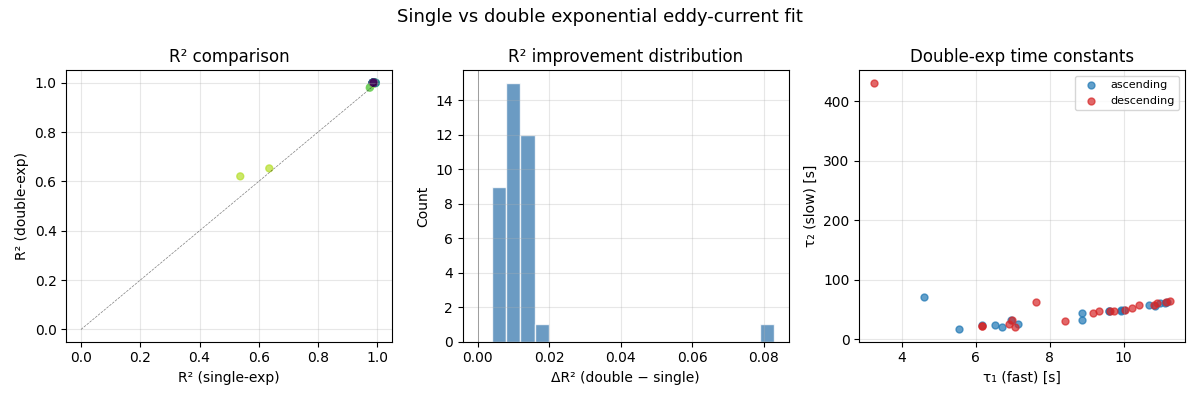


Runs where double-exp improved R² by >0.05: 1 / 38
Mean ΔR²: 0.0125
Max ΔR²:  0.0829


In [13]:
from rotating_coil_analyzer.analysis.utility_functions import double_eddy_model

dbl_records = []

for _, srow in df_fits_all.iterrows():
    run_id = int(srow["run_id"])
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue

    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    # Single-exp R²
    r2_single = srow["r2"]

    # Double-exp initial guesses from single-exp results
    B_inf_0 = srow["B_inf"]
    A_total = srow["A"]
    tau_single = srow["tau"]

    if not np.isfinite(tau_single):
        continue

    p0 = [B_inf_0, A_total * 0.5, tau_single / 3, A_total * 0.5, tau_single * 2]
    bounds_lo = [-np.inf, -np.inf, 0.5, -np.inf, 0.5]
    bounds_hi = [np.inf, np.inf, 500, np.inf, 2000]

    try:
        popt, pcov = curve_fit(
            double_eddy_model, turns, B1, p0=p0,
            bounds=(bounds_lo, bounds_hi), maxfev=20000,
        )
        B_inf, A1, tau1, A2, tau2 = popt

        # Enforce tau1 < tau2
        if tau1 > tau2:
            A1, A2 = A2, A1
            tau1, tau2 = tau2, tau1

        B1_pred = double_eddy_model(turns, *popt)
        ss_res = np.sum((B1 - B1_pred) ** 2)
        ss_tot = np.sum((B1 - B1.mean()) ** 2)
        r2_double = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        dbl_records.append({
            "run_id": run_id,
            "I_nom": srow["I_nom"],
            "branch": srow["branch"],
            "r2_single": r2_single,
            "r2_double": r2_double,
            "delta_r2": r2_double - r2_single,
            "tau1_s": tau1 * T_PER_TURN,
            "tau2_s": tau2 * T_PER_TURN,
            "A1": A1,
            "A2": A2,
            "B_inf": B_inf,
        })
    except (RuntimeError, ValueError) as e:
        dbl_records.append({
            "run_id": run_id,
            "I_nom": srow["I_nom"],
            "branch": srow["branch"],
            "r2_single": r2_single,
            "r2_double": np.nan,
            "delta_r2": np.nan,
            "tau1_s": np.nan,
            "tau2_s": np.nan,
            "A1": np.nan,
            "A2": np.nan,
            "B_inf": np.nan,
        })

df_dbl = pd.DataFrame(dbl_records)

# ── Comparison table ──
print("Double-exponential fit comparison:")
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
      f"{'R²_1exp':>8s} {'R²_2exp':>8s} {'ΔR²':>8s} "
      f"{'τ1 [s]':>8s} {'τ2 [s]':>8s}")
print("-" * 78)
for _, r in df_dbl.iterrows():
    r2d = f"{r['r2_double']:.4f}" if pd.notna(r['r2_double']) else "FAIL"
    dr = f"{r['delta_r2']:+.4f}" if pd.notna(r['delta_r2']) else "---"
    t1 = f"{r['tau1_s']:.1f}" if pd.notna(r['tau1_s']) else "---"
    t2 = f"{r['tau2_s']:.1f}" if pd.notna(r['tau2_s']) else "---"
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{r['r2_single']:8.4f} {r2d:>8s} {dr:>8s} "
          f"{t1:>8s} {t2:>8s}")

# ── Plots ──
valid = df_dbl.dropna(subset=["r2_double"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# (a) R² scatter
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=0.5, alpha=0.5)
ax.scatter(valid["r2_single"], valid["r2_double"], s=25, alpha=0.7,
           c=valid["I_nom"].abs(), cmap="viridis")
ax.set_xlabel("R² (single-exp)")
ax.set_ylabel("R² (double-exp)")
ax.set_title("R² comparison")

# (b) ΔR² histogram
ax = axes[1]
ax.hist(valid["delta_r2"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("ΔR² (double − single)")
ax.set_ylabel("Count")
ax.set_title("R² improvement distribution")

# (c) tau1 vs tau2
ax = axes[2]
for br, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
    mask = valid["branch"] == br
    if mask.any():
        ax.scatter(valid.loc[mask, "tau1_s"], valid.loc[mask, "tau2_s"],
                   s=25, alpha=0.7, color=col, label=br)
ax.set_xlabel("τ₁ (fast) [s]")
ax.set_ylabel("τ₂ (slow) [s]")
ax.set_title("Double-exp time constants")
ax.legend(fontsize=8)

fig.suptitle("Single vs double exponential eddy-current fit", fontsize=13)
fig.tight_layout()
plt.show()

# ── Summary ──
n_improved = (valid["delta_r2"] > 0.05).sum()
print(f"\nRuns where double-exp improved R² by >0.05: {n_improved} / {len(valid)}")
if len(valid) > 0:
    print(f"Mean ΔR²: {valid['delta_r2'].mean():.4f}")
    print(f"Max ΔR²:  {valid['delta_r2'].max():.4f}")